Statistically confident winner (p<0.05): 234 / 256 cells (91.4%)
Effectively tied with runner-up (p>=0.05): 22 / 256 cells


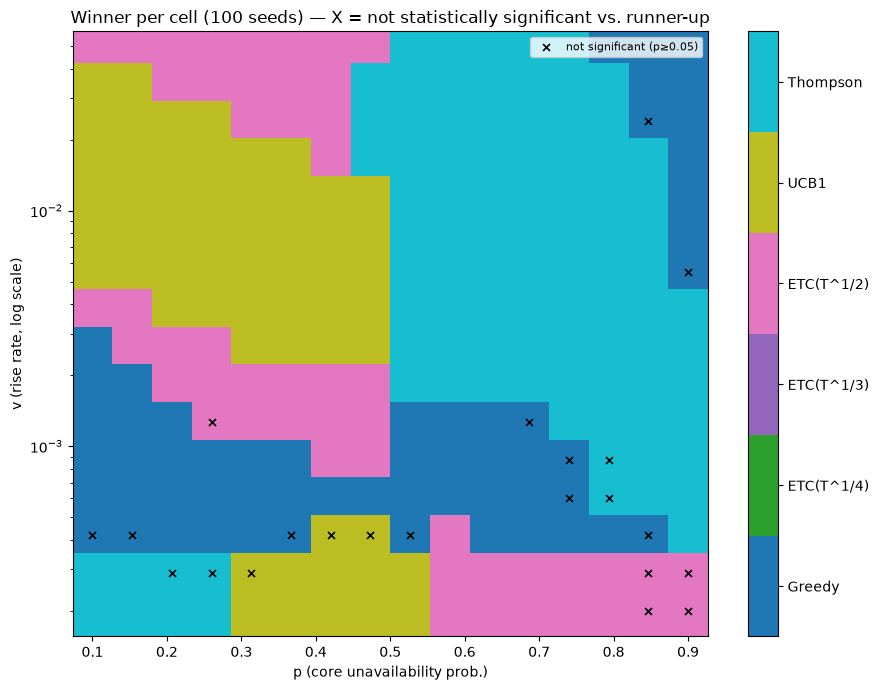

saved significance_winner_map.png


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

data = np.load("modal_multiseed_results.npz")
v_grid, p_grid, seeds = data["v_grid"], data["p_grid"], data["seeds"]
policy_names = [k for k in data.keys() if k not in ("v_grid", "p_grid", "seeds")]
n_seeds = len(seeds)
n_v, n_p = len(v_grid), len(p_grid)

# stacked shape: (n_policy, n_seeds, n_v, n_p)
stacked = np.stack([data[name] for name in policy_names], axis=0)
mean_regret = stacked.mean(axis=1)  # (n_policy, n_v, n_p) -- mean across the 10 seeds

winner_idx = np.zeros((n_v, n_p), dtype=int)
pvalue_grid = np.zeros((n_v, n_p))

for i in range(n_v):
    for j in range(n_p):
        order = np.argsort(mean_regret[:, i, j])  # ascending regret, best first
        best, second = order[0], order[1]
        winner_idx[i, j] = best
        a, b = stacked[best, :, i, j], stacked[second, :, i, j]
        if np.allclose(a, b):
            pvalue_grid[i, j] = 1.0
        else:
            _, pvalue_grid[i, j] = stats.ttest_rel(a, b)

significant = pvalue_grid < 0.05
print(f"Statistically confident winner (p<0.05): {significant.sum()} / {significant.size} cells ({100*significant.mean():.1f}%)")
print(f"Effectively tied with runner-up (p>=0.05): {(~significant).sum()} / {significant.size} cells")

# ---- plot: winner map, with an X marker over any cell that ISN'T significant ----
fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap("tab10", len(policy_names))
im = ax.pcolormesh(p_grid, v_grid, winner_idx, shading="auto", cmap=cmap, vmin=-0.5, vmax=len(policy_names)-0.5)
ax.set_yscale("log")

# overlay a marker at every NOT-significant cell -- placed at the exact
# (p,v) coordinate, so it aligns with pcolormesh regardless of shading mode
not_sig_p = [p_grid[j] for i in range(n_v) for j in range(n_p) if not significant[i, j]]
not_sig_v = [v_grid[i] for i in range(n_v) for j in range(n_p) if not significant[i, j]]
ax.scatter(not_sig_p, not_sig_v, marker="x", color="black", s=25, linewidths=1.2, label="not significant (p≥0.05)")

ax.set_xlabel("p (core unavailability prob.)")
ax.set_ylabel("v (rise rate, log scale)")
ax.set_title(f"Winner per cell ({n_seeds} seeds) — X = not statistically significant vs. runner-up")
ax.legend(loc="upper right", fontsize=8)
cbar = fig.colorbar(im, ax=ax, ticks=range(len(policy_names)))
cbar.ax.set_yticklabels(policy_names)
plt.tight_layout()
plt.savefig("significance_winner_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved significance_winner_map.png")